Présentation

# Préparation des données

## Quelles données vont-elles servir à l’apprentissage ?

Ce sont toutes les **colonnes descriptives** (*features*) qui peuvent aider à prédire le résultat, par exemple :

- `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`, etc.

On ne garde pas :

- `PassengerId` (juste un identifiant, inutile)
- `Name`, `Ticket`, `Cabin` (souvent peu utiles en brut sans traitement spécifique)

## Quelle variable va-t-elle servir de target ?

La variable cible est ici clairement la colonne **`Survived`**, qui indique si la personne a survécu (`1`) ou non (`0`).  
C’est ce que le modèle devra prédire.

## Nettoyage et traitement

- Nous avons **supprimé les personnes qui n’avaient pas de données (valeurs manquantes) dans une des colonnes conservées**.
- Nous avons également **converti la colonne `Sex` en binaire** :
  - `male → 1`
  - `female → 0`


(712, 8)
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    1  22.0      1      0   7.2500        S
1         1       1    0  38.0      1      0  71.2833        C
2         1       3    0  26.0      0      0   7.9250        S
3         1       1    0  35.0      1      0  53.1000        S
4         0       3    1  35.0      0      0   8.0500        S


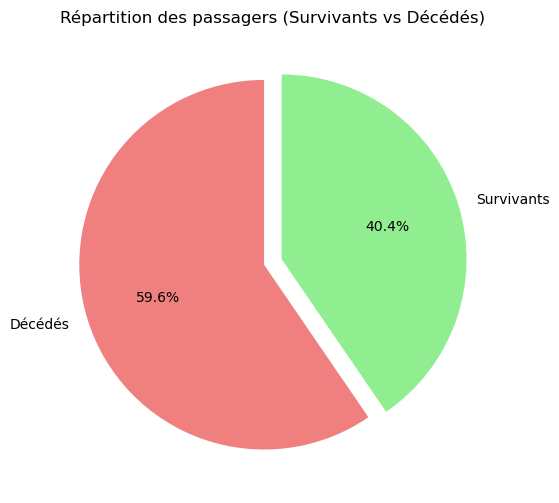

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données
df = pd.read_csv('old.csv')

# Encoder la colonne 'Sex' : male → 1, female → 0
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})


# 🔷 Supprimer les colonnes qu'on ne garde pas
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# 🔷 Supprimer les lignes avec valeurs manquantes dans les colonnes restantes
df = df.dropna()

# 🔷 Afficher la forme du dataframe après nettoyage
print(df.shape)
print(df.head())

# 🔷 Camembert des survivants et décédés
# Compter le nombre de 0 (décédés) et 1 (survivants)
counts = df['Survived'].value_counts()
labels = ['Décédés', 'Survivants']
colors = ['lightcoral', 'lightgreen']

plt.figure(figsize=(6,6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0.05))
plt.title('Répartition des passagers (Survivants vs Décédés)')
plt.show()


 analyse exploratoire complète


--- Aperçu des données ---
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    1  22.0      1      0   7.2500        S
1         1       1    0  38.0      1      0  71.2833        C
2         1       3    0  26.0      0      0   7.9250        S
3         1       1    0  35.0      1      0  53.1000        S
4         0       3    1  35.0      0      0   8.0500        S

--- Dimensions ---
(712, 8)

--- Types de données ---
Survived      int64
Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object

--- Valeurs manquantes par colonne ---
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

--- Statistiques descriptives ---
          Survived      Pclass         Sex         Age       SibSp  \
count   712.000000  712.000000  712.000000  712.000000  712.000000   
unique         NaN       

C:\Users\zakar\AppData\Local\Temp\ipykernel_25232\2441548508.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


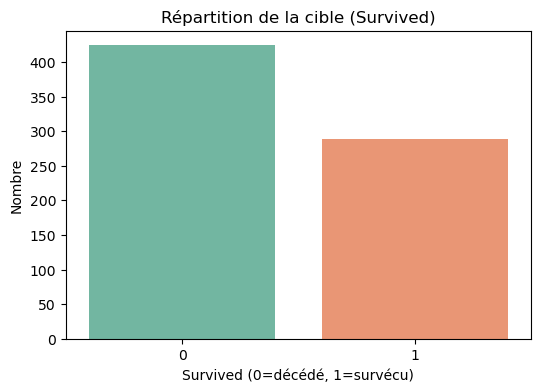

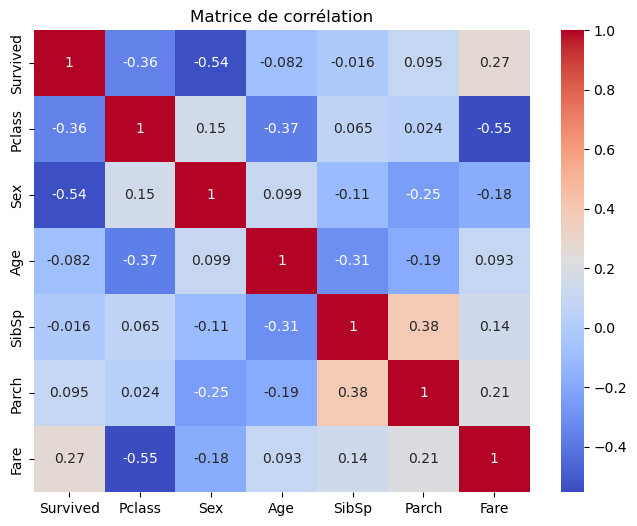

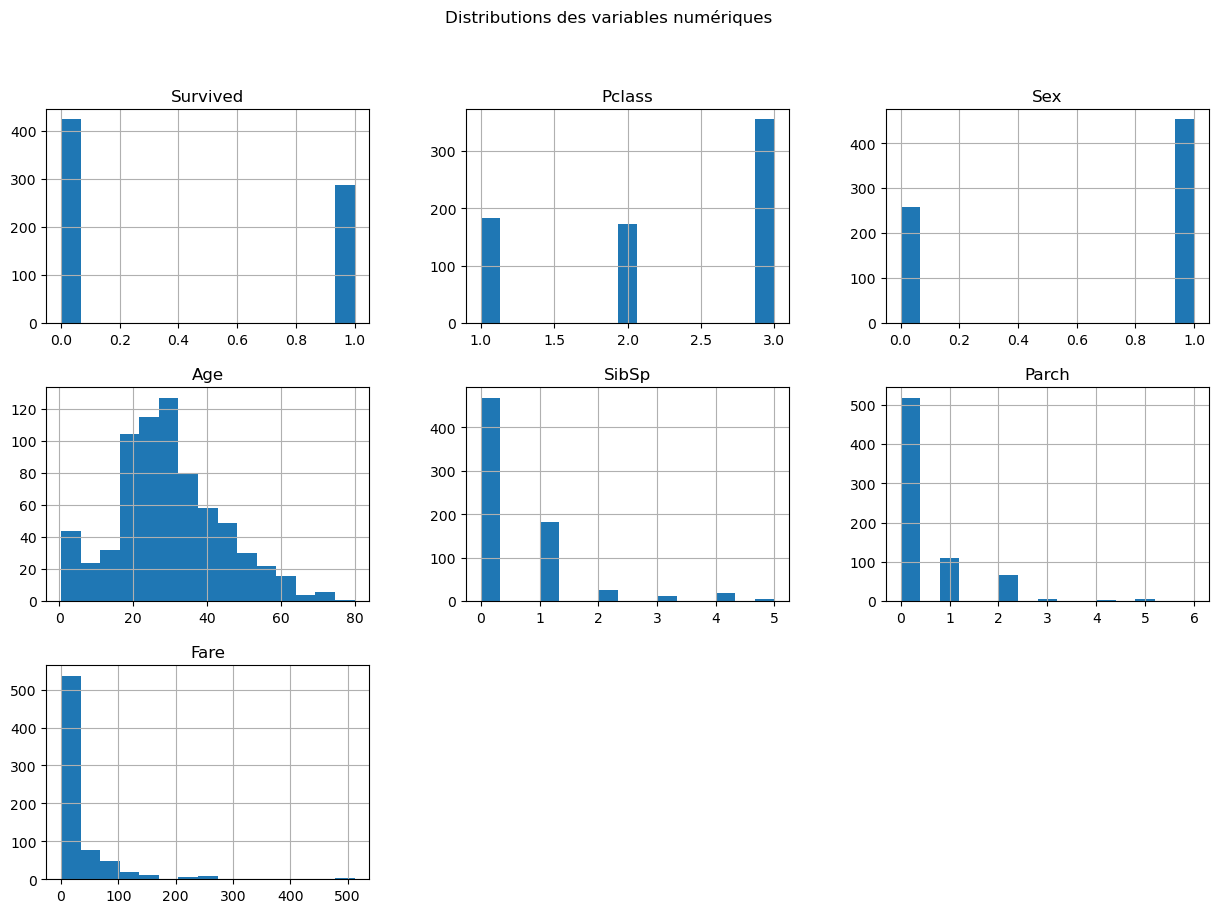

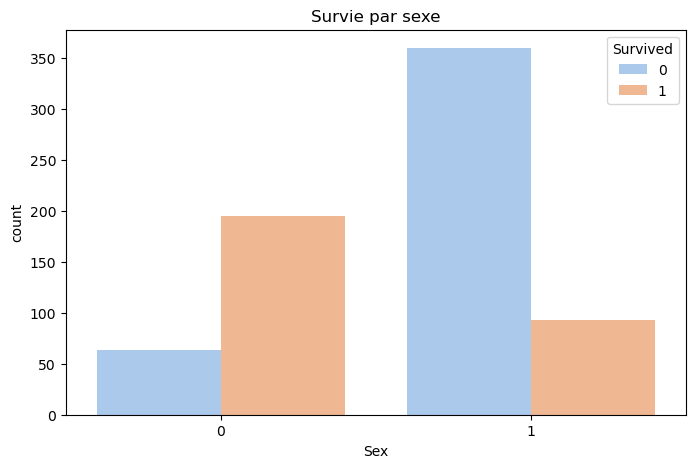

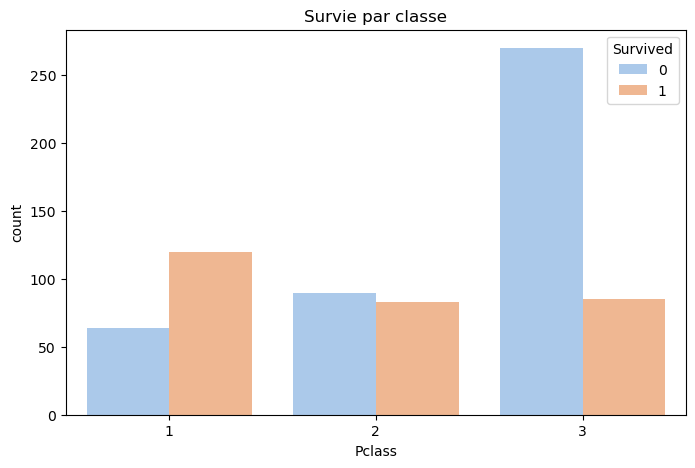

In [10]:

# 1️⃣ Aperçu général
print("\n--- Aperçu des données ---")
print(df.head())
print("\n--- Dimensions ---")
print(df.shape)
print("\n--- Types de données ---")
print(df.dtypes)

# 2️⃣ Valeurs manquantes
print("\n--- Valeurs manquantes par colonne ---")
print(df.isnull().sum())

# 3️⃣ Statistiques descriptives
print("\n--- Statistiques descriptives ---")
print(df.describe(include='all'))

# 4️⃣ Répartition de la cible
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Répartition de la cible (Survived)')
plt.xlabel('Survived (0=décédé, 1=survécu)')
plt.ylabel('Nombre')
plt.show()

# 5️⃣ Corrélations
# Garder uniquement les colonnes numériques
num_df = df.select_dtypes(include='number')

# Afficher la matrice de corrélation uniquement pour les colonnes numériques
plt.figure(figsize=(8,6))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.title('Matrice de corrélation')
plt.show()

# 6️⃣ Distributions des variables numériques
# Colonnes numériques
num_cols = df.select_dtypes(include='number').columns

# Option 1 : laisser pandas choisir le layout
df[num_cols].hist(bins=15, figsize=(15,10))
plt.suptitle('Distributions des variables numériques')
plt.show()

# 7️⃣ Répartition de la survie par sexe et classe
plt.figure(figsize=(8,5))
sns.countplot(x='Sex', hue='Survived', data=df, palette='pastel')
plt.title('Survie par sexe')
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='pastel')
plt.title('Survie par classe')
plt.show()